In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# -----------------------------------------------------------
# Q1: Quantum Teleportation of an ASCII Character
# -----------------------------------------------------------
#
# The program:
#   1. Accepts a single ASCII letter from the user.
#   2. Converts the letter to its 8-bit ASCII binary form.
#   3. Teleports each classical bit using quantum teleportation.
#   4. Measures Bob's reconstructed qubit.
#   5. Reconstructs the 8-bit binary string.
#   6. Converts the binary string back to a character.
#   7. Prints a PASS/FAIL verification result.
#
# Qubit layout for each teleportation:
#
#   q[0] = Alice's unknown/message qubit
#   q[1] = Alice's half of the Bell pair
#   q[2] = Bob's half of the Bell pair
#
# Classical bits:
#
#   c[0] = Alice's measurement of q[0]
#   c[1] = Alice's measurement of q[1]
#   c[2] = Bob's final measurement
#
# -----------------------------------------------------------


def teleport_bit(bit):
    """
    Teleport one classical bit (0 or 1) from Alice to Bob.

    Returns:
        bob_result: Bob's measured bit
        circuit:    The teleportation circuit
        alice_m0:   Alice's first measurement result
        alice_m1:   Alice's second measurement result
    """

    # -------------------------------------------------------
    # Create a circuit with:
    #   - 3 qubits
    #   - 3 classical bits
    #
    # q0 -> Alice's message qubit
    # q1 -> Alice's Bell-pair qubit
    # q2 -> Bob's Bell-pair qubit
    # -------------------------------------------------------
    circuit = QuantumCircuit(3, 3)

    # -------------------------------------------------------
    # STEP 1: Encode the classical bit into a qubit.
    #
    # |0> represents bit 0.
    # |1> represents bit 1.
    # -------------------------------------------------------
    if bit == 1:
        circuit.x(0)

    # -------------------------------------------------------
    # STEP 2: Create a Bell pair shared between Alice and Bob.
    #
    # H creates:
    #       (|0> + |1>) / sqrt(2)
    #
    # CNOT entangles Alice's q1 with Bob's q2:
    #
    #       |Phi+> = (|00> + |11>) / sqrt(2)
    # -------------------------------------------------------
    circuit.h(1)
    circuit.cx(1, 2)

    # -------------------------------------------------------
    # STEP 3: Alice performs the Bell-state measurement.
    #
    # First entangle the message qubit with Alice's Bell
    # qubit.
    # -------------------------------------------------------
    circuit.cx(0, 1)

    # Apply H to Alice's message qubit.
    circuit.h(0)

    # -------------------------------------------------------
    # STEP 4: Alice measures her two qubits.
    #
    # c[0] stores measurement of q[0]
    # c[1] stores measurement of q[1]
    # -------------------------------------------------------
    circuit.measure(0, 0)
    circuit.measure(1, 1)

    # -------------------------------------------------------
    # STEP 5: Classical communication and Bob's corrections.
    #
    # Alice's measurement results determine which corrections
    # Bob must apply.
    #
    # If Alice's second result is 1:
    #       Bob applies X.
    #
    # If Alice's first result is 1:
    #       Bob applies Z.
    #
    # Qiskit 2.x uses if_test() for these classical
    # conditions instead of the older c_if() interface.
    # -------------------------------------------------------
    with circuit.if_test((circuit.clbits[1], 1)):
        circuit.x(2)

    with circuit.if_test((circuit.clbits[0], 1)):
        circuit.z(2)

    # -------------------------------------------------------
    # STEP 6: Bob measures his reconstructed qubit.
    # -------------------------------------------------------
    circuit.measure(2, 2)

    # -------------------------------------------------------
    # Execute the circuit using AerSimulator.
    # One shot is sufficient here because the teleportation
    # circuit should reconstruct the computational-basis bit
    # exactly in an ideal noiseless simulation.
    # -------------------------------------------------------
    simulator = AerSimulator()

    compiled_circuit = transpile(circuit, simulator)

    result = simulator.run(
        compiled_circuit,
        shots=1
    ).result()

    counts = result.get_counts()

    # -------------------------------------------------------
    # Qiskit displays classical bits from highest index to
    # lowest index.
    #
    # Therefore:
    #
    #   key[0] -> c[2] -> Bob
    #   key[1] -> c[1] -> Alice's second measurement
    #   key[2] -> c[0] -> Alice's first measurement
    #
    # Example:
    #       "101"
    #
    # means:
    #   Bob = 1
    #   Alice second measurement = 0
    #   Alice first measurement = 1
    # -------------------------------------------------------
    measured_string = next(iter(counts))

    bob_result = int(measured_string[0])
    alice_m1 = int(measured_string[1])
    alice_m0 = int(measured_string[2])

    return bob_result, circuit, alice_m0, alice_m1


def letter_to_binary(letter):
    """
    Convert one ASCII character to an 8-bit binary string.

    Example:
        A -> 65 -> 01000001
    """

    ascii_value = ord(letter)

    return format(ascii_value, "08b")


def binary_to_letter(binary_string):
    """
    Convert an 8-bit binary string back to an ASCII character.
    """

    ascii_value = int(binary_string, 2)

    return chr(ascii_value)


# -----------------------------------------------------------
# Main program
# -----------------------------------------------------------

# Ask the user for a character.
letter = input("Enter one ASCII letter: ").strip()


# -----------------------------------------------------------
# Validate the input.
#
# The assignment asks for a letter, so we require:
#   - exactly one character
#   - an alphabetic character
#   - an ASCII character
# -----------------------------------------------------------
if len(letter) != 1:
    raise ValueError("Please enter exactly one letter.")

if not letter.isalpha():
    raise ValueError("Please enter a letter.")

if ord(letter) > 127:
    raise ValueError("Please enter an ASCII letter.")


# -----------------------------------------------------------
# STEP 1:
# Convert the original letter into its 8-bit ASCII binary
# representation.
# -----------------------------------------------------------
original_binary = letter_to_binary(letter)

print("\n==============================================")
print("QUANTUM TELEPORTATION")
print("==============================================")

print(f"Original letter: {letter}")
print(f"ASCII value:     {ord(letter)}")
print(f"Original binary: {original_binary}")


# -----------------------------------------------------------
# STEP 2–6:
# Teleport every bit independently.
#
# The ASCII representation contains exactly 8 bits.
# -----------------------------------------------------------
received_bits = []

print("\nBit-by-bit teleportation:")
print("----------------------------------------------")

for index, bit_character in enumerate(original_binary):

    transmitted_bit = int(bit_character)

    # Teleport this individual bit.
    bob_bit, circuit, alice_m0, alice_m1 = teleport_bit(
        transmitted_bit
    )

    received_bits.append(str(bob_bit))

    # Print the required verification information.
    print(
        f"Bit {index + 1}: "
        f"sent = {transmitted_bit}, "
        f"Alice measurements = ({alice_m0}, {alice_m1}), "
        f"Bob = {bob_bit}"
    )


# -----------------------------------------------------------
# STEP 7:
# Reconstruct the complete 8-bit binary string.
# -----------------------------------------------------------
reconstructed_binary = "".join(received_bits)

# Convert the reconstructed binary string back to a letter.
reconstructed_letter = binary_to_letter(
    reconstructed_binary
)


# -----------------------------------------------------------
# Verification
# -----------------------------------------------------------

print("\n==============================================")
print("VERIFICATION")
print("==============================================")

print(f"Original binary:      {original_binary}")
print(f"Reconstructed binary: {reconstructed_binary}")

print(f"Original letter:      {letter}")
print(f"Recovered letter:     {reconstructed_letter}")


# -----------------------------------------------------------
# PASS / FAIL check
# -----------------------------------------------------------
if (
    reconstructed_binary == original_binary
    and reconstructed_letter == letter
):
    print("\nRESULT: PASS")
    print("Quantum teleportation successfully reconstructed the letter.")
else:
    print("\nRESULT: FAIL")
    print("The reconstructed letter does not match the original.")

/var/folders/4b/rwy5gwj50nq31lwlqwjy2btw0000gn/T/ipykernel_20132/2334549649.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit, transpile


Enter one ASCII letter: A

QUANTUM TELEPORTATION
Original letter: A
ASCII value:     65
Original binary: 01000001

Bit-by-bit teleportation:
----------------------------------------------
Bit 1: sent = 0, Alice measurements = (1, 1), Bob = 0
Bit 2: sent = 1, Alice measurements = (0, 0), Bob = 1
Bit 3: sent = 0, Alice measurements = (0, 1), Bob = 0
Bit 4: sent = 0, Alice measurements = (0, 0), Bob = 0
Bit 5: sent = 0, Alice measurements = (0, 1), Bob = 0
Bit 6: sent = 0, Alice measurements = (0, 1), Bob = 0
Bit 7: sent = 0, Alice measurements = (0, 1), Bob = 0
Bit 8: sent = 1, Alice measurements = (1, 0), Bob = 1

VERIFICATION
Original binary:      01000001
Reconstructed binary: 01000001
Original letter:      A
Recovered letter:     A

RESULT: PASS
Quantum teleportation successfully reconstructed the letter.



Quantum circuit for teleporting one bit:


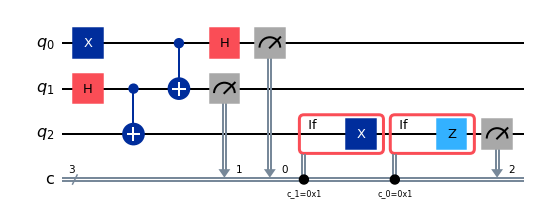

In [2]:
# Display the circuit for one example bit.
example_bit = 1

bob_bit, example_circuit, alice_m0, alice_m1 = teleport_bit(example_bit)

print("\nQuantum circuit for teleporting one bit:")

display(example_circuit.draw("mpl"))

Why quantum teleportation transfers a quantum state rather than physical matter:
Quantum teleportation transfers the information contained in a quantum state from one qubit to another; 
it does not physically transport matter or the original particle. Alice and Bob first share an entangled pair of qubits. Alice performs a Bell-state measurement on the state to be teleported and her entangled qubit. This measurement destroys the original state at Alice's side. Bob's qubit can then be transformed into the original state using Alice's measurement results.

Why classical communication is required:
Alice must send the two classical measurement results to Bob. These results tell Bob whether he needs
to apply an X correction, a Z correction, or both to his qubit. Without this classical information, 
Bob cannot reconstruct the original state. Therefore, quantum teleportation requires
both shared entanglement and classical communication and cannot be used for faster-than-light communication.

In [11]:
import random
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


# =========================================================
# BB84 Quantum Key Distribution: Eavesdropper Detection
# =========================================================

# Number of qubits transmitted by Alice.
# A larger number gives more stable statistical results.
N = 1000

# Fraction of the sifted key used as publicly revealed check bits.
CHECK_FRACTION = 0.5

# Error-rate threshold used by this simulation to decide
# whether the protocol should be aborted.
QBER_THRESHOLD = 0.11

# Fix the seed so that the experiment can be reproduced.
SEED = 42

simulator = AerSimulator()


# =========================================================
# 1. Alice prepares a BB84 state
# =========================================================

def prepare_bb84_state(bit, basis):
    """
    Prepare one of the four BB84 states.

    basis = 0 -> Z basis
        bit 0 -> |0>
        bit 1 -> |1>

    basis = 1 -> X basis
        bit 0 -> |+>
        bit 1 -> |->

    The circuit returned by this function represents
    the state transmitted to the next party.
    """

    qc = QuantumCircuit(1, 1)

    if basis == 0:
        # Z basis:
        # The initial state is |0>.
        # Apply X only when the encoded bit is 1,
        # producing |1>.
        if bit == 1:
            qc.x(0)

    else:
        # X basis:
        # First prepare |0> or |1>, then apply H
        # to obtain |+> or |->.
        if bit == 1:
            qc.x(0)

        qc.h(0)

    return qc


# =========================================================
# 2. Measure a qubit in the chosen basis
# =========================================================

def measure_qubit(qc, basis):
    """
    Measure one qubit in the Z or X basis.

    A Z-basis measurement is performed directly.

    For an X-basis measurement, H is applied first.
    This rotates the X basis into the computational basis,
    allowing the standard measurement to be used.
    """

    circuit = qc.copy()

    if basis == 1:
        circuit.h(0)

    circuit.measure(0, 0)

    result = simulator.run(circuit, shots=1).result()
    counts = result.get_counts()

    return int(next(iter(counts)))


# =========================================================
# 3. Run one BB84 experiment
# =========================================================

def run_bb84(eve=False):
    """
    Run the complete BB84 protocol.

    eve=False:
        Alice sends her prepared states directly to Bob.

    eve=True:
        Eve performs an intercept-and-resend attack.

    The function returns the number of sifted bits,
    the number of check bits, the observed QBER,
    and the final protocol decision.
    """

    # -----------------------------------------------------
    # Alice generates random bits and random bases.
    # -----------------------------------------------------

    alice_bits = [
        random.randint(0, 1)
        for _ in range(N)
    ]

    alice_bases = [
        random.randint(0, 1)
        for _ in range(N)
    ]

    # -----------------------------------------------------
    # Bob independently chooses his measurement bases.
    # -----------------------------------------------------

    bob_bases = [
        random.randint(0, 1)
        for _ in range(N)
    ]

    # -----------------------------------------------------
    # Eve independently chooses an interception basis.
    # These choices are used only when Eve is present.
    # -----------------------------------------------------

    eve_bases = [
        random.randint(0, 1)
        for _ in range(N)
    ]

    # -----------------------------------------------------
    # Alice prepares the quantum states.
    # -----------------------------------------------------

    alice_circuits = [
        prepare_bb84_state(bit, basis)
        for bit, basis in zip(alice_bits, alice_bases)
    ]

    # -----------------------------------------------------
    # Quantum channel
    # -----------------------------------------------------

    if eve:
        transmitted_circuits = []

        for circuit, eve_basis in zip(alice_circuits, eve_bases):

            # Eve intercepts the qubit and measures it
            # without knowing Alice's preparation basis.
            eve_bit = measure_qubit(circuit, eve_basis)

            # Eve creates a new qubit from her measurement
            # result and resends it to Bob.
            resent_circuit = prepare_bb84_state(
                eve_bit,
                eve_basis
            )

            transmitted_circuits.append(resent_circuit)

    else:
        # In the ideal no-Eve case, Bob receives
        # Alice's original states unchanged.
        transmitted_circuits = alice_circuits

    # -----------------------------------------------------
    # Bob measures each received qubit.
    # -----------------------------------------------------

    bob_results = [
        measure_qubit(circuit, basis)
        for circuit, basis in zip(
            transmitted_circuits,
            bob_bases
        )
    ]

    # -----------------------------------------------------
    # Sifting
    # -----------------------------------------------------

    # Alice and Bob publicly compare only their bases.
    # They keep positions where they selected the same basis.
    sifted_positions = [
        i
        for i in range(N)
        if alice_bases[i] == bob_bases[i]
    ]

    alice_sifted = [
        alice_bits[i]
        for i in sifted_positions
    ]

    bob_sifted = [
        bob_results[i]
        for i in sifted_positions
    ]

    # -----------------------------------------------------
    # Check-bit selection
    # -----------------------------------------------------

    # A random subset of the sifted bits is revealed publicly
    # to estimate the error rate. These bits cannot later be
    # used as secret-key bits.
    num_check = max(
        1,
        int(len(alice_sifted) * CHECK_FRACTION)
    )

    check_positions = random.sample(
        range(len(alice_sifted)),
        num_check
    )

    alice_check = [
        alice_sifted[i]
        for i in check_positions
    ]

    bob_check = [
        bob_sifted[i]
        for i in check_positions
    ]

    # -----------------------------------------------------
    # QBER calculation
    # -----------------------------------------------------

    # Count mismatches between Alice's and Bob's
    # publicly compared check bits.
    errors = sum(
        a != b
        for a, b in zip(alice_check, bob_check)
    )

    qber = errors / len(alice_check)

    # Abort when the observed error rate is above
    # the threshold selected for this simulation.
    accepted = qber <= QBER_THRESHOLD

    return {
        "sifted_bits": len(alice_sifted),
        "check_bits": len(alice_check),
        "qber": qber,
        "accepted": accepted
    }


# =========================================================
# 4. Run the two experiments
# =========================================================

# Run without Eve.
random.seed(SEED)
no_eve_results = run_bb84(eve=False)

# Run with intercept-and-resend Eve.
# Using the same seed makes the random initial conditions
# comparable between the two experiments.
random.seed(SEED)
eve_results = run_bb84(eve=True)


# =========================================================
# 5. Display the results
# =========================================================

print("=" * 60)
print("BB84 SECURITY SIMULATION")
print("=" * 60)

print("\nWithout Eve")
print("-" * 60)
print(f"Sifted bits : {no_eve_results['sifted_bits']}")
print(f"Check bits  : {no_eve_results['check_bits']}")
print(f"QBER        : {no_eve_results['qber']:.2%}")

if no_eve_results["accepted"]:
    print("Decision    : PASS")
else:
    print("Decision    : ABORT")


print("\nWith Eve (Intercept-and-Resend)")
print("-" * 60)
print(f"Sifted bits : {eve_results['sifted_bits']}")
print(f"Check bits  : {eve_results['check_bits']}")
print(f"QBER        : {eve_results['qber']:.2%}")

if eve_results["accepted"]:
    print("Decision    : PASS")
else:
    print("Decision    : ABORT")


# =========================================================
# 6. Comparison table
# =========================================================

print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)

print(
    f"{'Scenario':<30}"
    f"{'Sifted':>10}"
    f"{'QBER':>10}"
    f"{'Decision':>10}"
)

print("-" * 60)

print(
    f"{'No Eve':<30}"
    f"{no_eve_results['sifted_bits']:>10}"
    f"{no_eve_results['qber']:>9.2%}"
    f"{'PASS' if no_eve_results['accepted'] else 'ABORT':>10}"
)

print(
    f"{'Intercept-and-Resend Eve':<30}"
    f"{eve_results['sifted_bits']:>10}"
    f"{eve_results['qber']:>9.2%}"
    f"{'PASS' if eve_results['accepted'] else 'ABORT':>10}"
)

BB84 SECURITY SIMULATION

Without Eve
------------------------------------------------------------
Sifted bits : 486
Check bits  : 243
QBER        : 0.00%
Decision    : PASS

With Eve (Intercept-and-Resend)
------------------------------------------------------------
Sifted bits : 486
Check bits  : 243
QBER        : 21.40%
Decision    : ABORT

COMPARISON
Scenario                          Sifted      QBER  Decision
------------------------------------------------------------
No Eve                               486    0.00%      PASS
Intercept-and-Resend Eve             486   21.40%     ABORT


In the ideal simulation without eavesdropping, the observed QBER was 0.00%, so the protocol passed the security check. With an intercept-and-resend attack, the observed QBER increased to 21.40%, exceeding the 11% threshold, causing the protocol to abort. This demonstrates that eavesdropping introduces detectable errors into the sifted key.

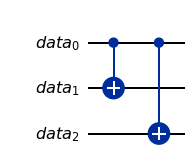

In [29]:
from qiskit import QuantumCircuit, QuantumRegister
from IPython.display import display

# Create three physical data qubits.
# data[0] holds the original logical qubit,
# while data[1] and data[2] are initialized to |0>.
data = QuantumRegister(3, "data")

# Create the quantum circuit containing the three data qubits.
qc_encode = QuantumCircuit(data)

# First CNOT:
# Use data[0] as the control and data[1] as the target.
# This correlates the second physical qubit with the logical qubit.
qc_encode.cx(data[0], data[1])

# Second CNOT:
# Use data[0] as the control and data[2] as the target.
# After both CNOTs, the logical state
# alpha|0> + beta|1> is encoded as
# alpha|000> + beta|111>.
qc_encode.cx(data[0], data[2])

# Display the encoding circuit using Qiskit's graphical
# Matplotlib renderer.
display(qc_encode.draw("mpl"))

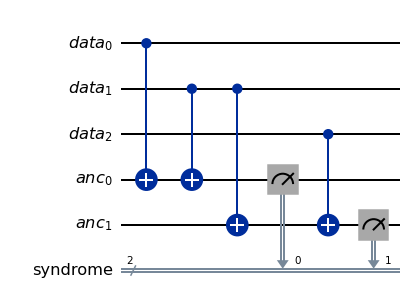

In [30]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display

# Create three physical data qubits that contain the encoded logical state.
data = QuantumRegister(3, "data")

# Create two ancilla qubits used to extract the two parity checks.
# The ancillas begin in |0> and will store the syndrome information.
anc = QuantumRegister(2, "anc")

# Create two classical bits to record the measured syndrome.
syndrome = ClassicalRegister(2, "syndrome")

# Construct the circuit containing the data qubits, syndrome ancillas,
# and classical syndrome register.
qc_syndrome = QuantumCircuit(data, anc, syndrome)

# -------------------------------------------------
# First parity check: compare q0 and q1
# -------------------------------------------------

# Copy the value of q0 into ancilla a0 using a CNOT.
# Since a0 starts in |0>, it becomes q0.
qc_syndrome.cx(data[0], anc[0])

# XOR q1 into the same ancilla.
# The final ancilla value is therefore q0 XOR q1.
# This parity check detects whether q0 and q1 differ.
qc_syndrome.cx(data[1], anc[0])

# -------------------------------------------------
# Second parity check: compare q1 and q2
# -------------------------------------------------

# Copy q1 into the second ancilla.
qc_syndrome.cx(data[1], anc[1])

# XOR q2 into the same ancilla.
# The final value of a1 is q1 XOR q2,
# which detects whether q1 and q2 differ.
qc_syndrome.cx(data[2], anc[1])

# -------------------------------------------------
# Measure the syndrome
# -------------------------------------------------

# Measure the first ancilla and store the result
# in the first classical syndrome bit.
qc_syndrome.measure(anc[0], syndrome[0])

# Measure the second ancilla and store the result
# in the second classical syndrome bit.
# Together, these two classical bits identify
# the location of a possible single X error.
qc_syndrome.measure(anc[1], syndrome[1])

# Display the syndrome-extraction circuit using
# Qiskit's graphical Matplotlib renderer.
display(qc_syndrome.draw("mpl"))


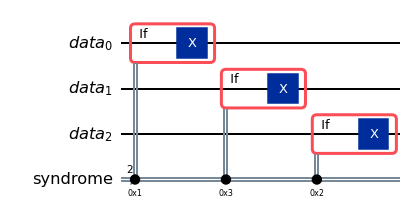

In [31]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display

# Create the three physical data qubits.
# These qubits contain the encoded logical state that will be corrected.
data = QuantumRegister(3, "data")

# Create a two-bit classical register to store the measured error syndrome.
syndrome = ClassicalRegister(2, "syndrome")

# Construct the circuit containing the data qubits and syndrome register.
qc_correction = QuantumCircuit(data, syndrome)

# -------------------------------------------------
# Conditional error correction
# -------------------------------------------------

# If the measured syndrome is 01, the error occurred on q0.
# Apply X to q0 to reverse the detected bit-flip error.
with qc_correction.if_test((syndrome, 0b01)):
    qc_correction.x(data[0])

# If the measured syndrome is 11, the error occurred on q1.
# Apply X to q1 to reverse the detected bit-flip error.
with qc_correction.if_test((syndrome, 0b11)):
    qc_correction.x(data[1])

# If the measured syndrome is 10, the error occurred on q2.
# Apply X to q2 to reverse the detected bit-flip error.
with qc_correction.if_test((syndrome, 0b10)):
    qc_correction.x(data[2])

# The syndrome 00 corresponds to the no-error case,
# so no correction operation is applied.

# Display the conditional correction circuit using
# Qiskit's graphical Matplotlib renderer.
display(qc_correction.draw("mpl"))


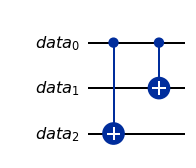

In [32]:
from qiskit import QuantumCircuit, QuantumRegister
from IPython.display import display

# Create the three physical data qubits containing the corrected
# encoded logical state.
data = QuantumRegister(3, "data")

# Construct the decoding circuit.
qc_decode = QuantumCircuit(data)

# -------------------------------------------------
# Decode the logical qubit
# -------------------------------------------------

# First undo the second encoding CNOT.
# q0 is the control and q2 is the target.
# This removes the correlation between q0 and q2.
qc_decode.cx(data[0], data[2])

# Then undo the first encoding CNOT.
# q0 is the control and q1 is the target.
# After both operations, the logical state is recovered
# in q0, while q1 and q2 return to |0>.
qc_decode.cx(data[0], data[1])

# Display the decoding circuit using Qiskit's
# graphical Matplotlib renderer.
display(qc_decode.draw("mpl"))

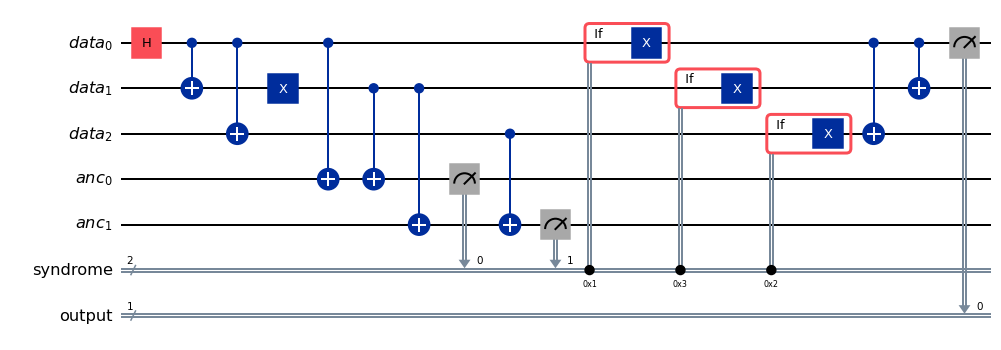

In [27]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display


data = QuantumRegister(3, "data")
anc = QuantumRegister(2, "anc")
syndrome = ClassicalRegister(2, "syndrome")
output = ClassicalRegister(1, "output")

qc_complete = QuantumCircuit(data, anc, syndrome, output)

# -------------------------------------------------
# 1. Prepare |+>
# -------------------------------------------------
qc_complete.h(data[0])

# -------------------------------------------------
# 2. Encode
# -------------------------------------------------
qc_complete.cx(data[0], data[1])
qc_complete.cx(data[0], data[2])

# -------------------------------------------------
# 3. Inject X1 error
# -------------------------------------------------
qc_complete.x(data[1])

# -------------------------------------------------
# 4. Syndrome extraction
# -------------------------------------------------
qc_complete.cx(data[0], anc[0])
qc_complete.cx(data[1], anc[0])

qc_complete.cx(data[1], anc[1])
qc_complete.cx(data[2], anc[1])

# -------------------------------------------------
# 5. Measure syndrome
# -------------------------------------------------
qc_complete.measure(anc[0], syndrome[0])
qc_complete.measure(anc[1], syndrome[1])

# -------------------------------------------------
# 6. Conditional correction
# -------------------------------------------------
with qc_complete.if_test((syndrome, 0b01)):
    qc_complete.x(data[0])

with qc_complete.if_test((syndrome, 0b11)):
    qc_complete.x(data[1])

with qc_complete.if_test((syndrome, 0b10)):
    qc_complete.x(data[2])

# -------------------------------------------------
# 7. Decode
# -------------------------------------------------
qc_complete.cx(data[0], data[2])
qc_complete.cx(data[0], data[1])

# -------------------------------------------------
# 8. Measure recovered logical qubit
# -------------------------------------------------
qc_complete.measure(data[0], output[0])

display(qc_complete.draw("mpl"))



In [33]:
from qiskit_aer import AerSimulator
# Use Qiskit Aer to run the complete QEC circuit on

# an ideal shot-based quantum simulator.
simulator = AerSimulator()

# Execute the circuit 1000 times.
# Repeating the circuit allows us to estimate the
# measurement probabilities statistically.
result = simulator.run(qc_complete , shots=1000).result()


# Extract the measured classical outcomes and their
# frequencies from the simulation result.
counts = result.get_counts()

# Display the measurement counts for verification.

print(counts)

{'0 11': 502, '1 11': 498}


In [11]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display


def build_qec_circuit(input_state, error_location=None):
    """
    Build a three-qubit bit-flip QEC circuit.

    Parameters
    ----------
    input_state : str
        "0", "1", or "+".
    error_location : int or None
        None  -> no error
        0     -> X error on data qubit 0
        1     -> X error on data qubit 1
        2     -> X error on data qubit 2

    Returns
    -------
    QuantumCircuit
        Complete QEC circuit.
    """

    # -------------------------
    # Registers
    # -------------------------

    data = QuantumRegister(3, "data")
    anc = QuantumRegister(2, "anc")
    syndrome = ClassicalRegister(2, "syndrome")
    output = ClassicalRegister(1, "output")

    qc = QuantumCircuit(data, anc, syndrome, output)

    # -------------------------
    # 1. Prepare input state
    # -------------------------

    if input_state == "0":
        # |0> is already the initial state
        pass

    elif input_state == "1":
        qc.x(data[0])

    elif input_state == "+":
        qc.h(data[0])

    else:
        raise ValueError(
            "input_state must be '0', '1', or '+'."
        )

    # -------------------------
    # 2. Encode
    # -------------------------

    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    # -------------------------
    # 3. Inject single X error
    # -------------------------

    if error_location is None:
        pass

    elif error_location in (0, 1, 2):
        qc.x(data[error_location])

    else:
        raise ValueError(
            "error_location must be None, 0, 1, 2."
        )

    # -------------------------
    # 4. Syndrome extraction
    #
    # anc[0] = q0 XOR q1
    # anc[1] = q1 XOR q2
    # -------------------------

    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])

    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])

    # -------------------------
    # 5. Measure syndrome
    # -------------------------

    qc.measure(anc[0], syndrome[0])
    qc.measure(anc[1], syndrome[1])

    # -------------------------
    # 6. Conditional correction
    #
    # Qiskit integer values:
    #
    # 01 -> X0
    # 11 -> X1
    # 10 -> X2
    # -------------------------

    with qc.if_test((syndrome, 0b01)):
        qc.x(data[0])

    with qc.if_test((syndrome, 0b11)):
        qc.x(data[1])

    with qc.if_test((syndrome, 0b10)):
        qc.x(data[2])

    # -------------------------
    # 7. Decode
    # -------------------------

    qc.cx(data[0], data[2])
    qc.cx(data[0], data[1])

    # -------------------------
    # 8. Measure recovered
    # logical qubit
    # -------------------------

    qc.measure(data[0], output[0])

    return qc

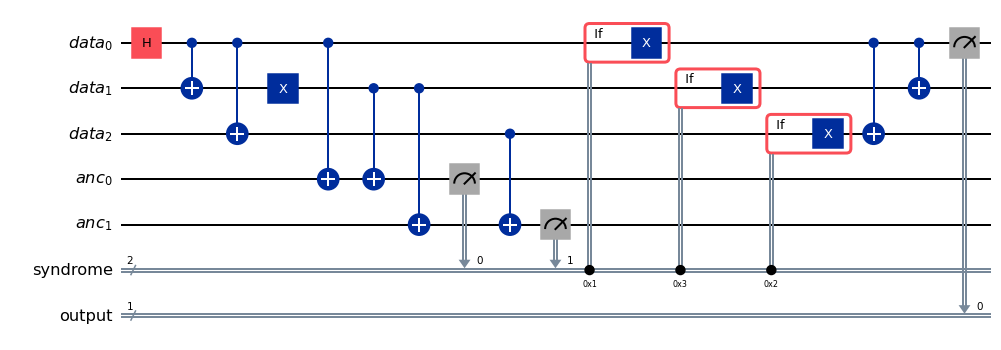

In [12]:
qc_test = build_qec_circuit("+", 1)

display(qc_test.draw("mpl"))

In [13]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

result = simulator.run(
    qc_test,
    shots=1000
).result()

counts = result.get_counts()

print(counts)

{'1 11': 499, '0 11': 501}


In [14]:
tests = {
    "no_error": None,
    "X0": 0,
    "X1": 1,
    "X2": 2,
}

for label, error_location in tests.items():
    qc_test = build_qec_circuit("+", error_location)

    result = simulator.run(
        qc_test,
        shots=1000
    ).result()

    counts = result.get_counts()

    print(f"{label}: {counts}")

no_error: {'0 00': 499, '1 00': 501}
X0: {'0 01': 503, '1 01': 497}
X1: {'1 11': 515, '0 11': 485}
X2: {'1 10': 461, '0 10': 539}


In [15]:
tests = {
    "no_error": None,
    "X0": 0,
    "X1": 1,
    "X2": 2,
}

print("Input state: |0>")

for label, error_location in tests.items():
    qc_test = build_qec_circuit("0", error_location)

    result = simulator.run(
        qc_test,
        shots=1000
    ).result()

    counts = result.get_counts()

    print(f"{label}: {counts}")

Input state: |0>
no_error: {'0 00': 1000}
X0: {'0 01': 1000}
X1: {'0 11': 1000}
X2: {'0 10': 1000}


In [16]:
print("Input state: |1>")

for label, error_location in tests.items():
    qc_test = build_qec_circuit("1", error_location)

    result = simulator.run(
        qc_test,
        shots=1000
    ).result()

    counts = result.get_counts()

    print(f"{label}: {counts}")

Input state: |1>
no_error: {'1 00': 1000}
X0: {'1 01': 1000}
X1: {'1 11': 1000}
X2: {'1 10': 1000}


In [17]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display

def build_unprotected_circuit(input_state, error_location):
    """
    Build an unprotected single-qubit circuit.

    Parameters
    ----------
    input_state : str
        "0", "1", or "+".
    error_location : int or None
        For the unprotected case, only None or 0 is meaningful,
        because there is only one physical qubit.

    Returns
    -------
    QuantumCircuit
        Single-qubit circuit with optional X error.
    """

    qubit = QuantumRegister(1, "q")
    output = ClassicalRegister(1, "output")

    qc = QuantumCircuit(qubit, output)

    # Prepare input state
    if input_state == "0":
        pass

    elif input_state == "1":
        qc.x(qubit[0])

    elif input_state == "+":
        qc.h(qubit[0])

    else:
        raise ValueError(
            "input_state must be '0', '1', or '+'."
        )

    # Apply X error
    if error_location is not None:
        if error_location != 0:
            raise ValueError(
                "An unprotected circuit has only one physical qubit: q0."
            )
        qc.x(qubit[0])

    # Measure
    qc.measure(qubit[0], output[0])

    return qc

In [18]:
qc_unprotected = build_unprotected_circuit("0", 0)

result_unprotected = simulator.run(
    qc_unprotected,
    shots=1000
).result()

counts_unprotected = result_unprotected.get_counts()

print(counts_unprotected)

{'1': 1000}


In [19]:
qc_unprotected = build_unprotected_circuit("0", 0)

result_unprotected = simulator.run(
    qc_unprotected,
    shots=1000
).result()

print(result_unprotected.get_counts())

{'1': 1000}


In [20]:
qc_unprotected_1 = build_unprotected_circuit("1", 0)

result = simulator.run(
    qc_unprotected_1,
    shots=1000
).result()

print(result.get_counts())

{'0': 1000}


In [21]:
simulator = AerSimulator()

result = simulator.run(
    qc_test,
    shots=1000
).result()

counts = result.get_counts()

In [22]:
from qiskit_aer import AerSimulator

def run_circuit(qc, shots=1000):
    """
    Run a Qiskit circuit on an ideal shot-based simulator.

    Parameters
    ----------
    qc : QuantumCircuit
        Circuit to simulate.
    shots : int
        Number of measurement shots.

    Returns
    -------
    dict
        Measurement counts.
    """
    simulator = AerSimulator()

    result = simulator.run(
        qc,
        shots=shots
    ).result()

    return result.get_counts()

In [23]:
counts = run_circuit(qc_test, shots=1000)
print(counts)

{'1 10': 1000}


In [24]:
import pandas as pd

results = [
    ["|0>", "None", "00", "0", "1000"],
    ["|0>", "X0",   "01", "0", "1000"],
    ["|0>", "X1",   "11", "0", "1000"],
    ["|0>", "X2",   "10", "0", "1000"],

    ["|1>", "None", "00", "1", "1000"],
    ["|1>", "X0",   "01", "1", "1000"],
    ["|1>", "X1",   "11", "1", "1000"],
    ["|1>", "X2",   "10", "1", "1000"],

    ["|+>", "None", "00", "|+>", "0:502, 1:498"],
    ["|+>", "X0",   "01", "|+>", "0:520, 1:480"],
    ["|+>", "X1",   "11", "|+>", "0:505, 1:495"],
    ["|+>", "X2",   "10", "|+>", "0:488, 1:512"],
]

df = pd.DataFrame(
    results,
    columns=[
        "Input",
        "Error",
        "Syndrome",
        "Expected",
        "Observed"
    ]
)

display(df)

,Input,Error,Syndrome,Expected,Observed
0,|0>,None,00,0,1000
1,|0>,X0,01,0,1000
2,|0>,X1,11,0,1000
3,|0>,X2,10,0,1000
4,|1>,None,00,1,1000
5,|1>,X0,01,1,1000
6,|1>,X1,11,1,1000
7,|1>,X2,10,1,1000
8,|+>,None,00,|+>,"0:502, 1:498"
9,|+>,X0,01,|+>,"0:520, 1:480"
